# Flumy Data Generation Pipeline Demo

This notebook demonstrates an end-to-end workflow:
1. Generate a 3D facies model with Flumy
2. Visualize the 3D facies model (static)
3. Extract and visualize slices
4. Convert facies to Acoustic Impedance (AI)
5. Compute reflectivity and visualize it (slice + 3D view)
6. Generate and visualize RMS attributes

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Optional for static 3D plotting
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Ensure project root is importable when notebook is opened from notebooks/
repo_root = Path.cwd().resolve()
if not (repo_root / "diffsim").exists():
    candidate = repo_root.parent
    if (candidate / "diffsim").exists():
        os.chdir(candidate)
        repo_root = candidate

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(f"Repository root: {repo_root}")
print("Imports complete.")

from diffsim.data.flumy_generator import FlumyGenerator
from diffsim.data.seismic import (
    DEFAULT_AI,
    generate_rms_from_facies_3d,
)

Repository root: /home/tharitt/working/DiffSim
Imports complete.


/home/tharitt/working/DiffSim/.venv/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Reproducible random behavior for noise and plot sampling
rng = np.random.default_rng(42)

flgen = FlumyGenerator(
    hmax=10.0,
    ng=45,
    isbx=20,
    verbose=False,
)

facies_block_raw = flgen.generate(seed=7)
facies_block = FlumyGenerator.reclassify_to_three_facies(facies_block_raw)


/tmp/ipykernel_1966012/4159612985.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


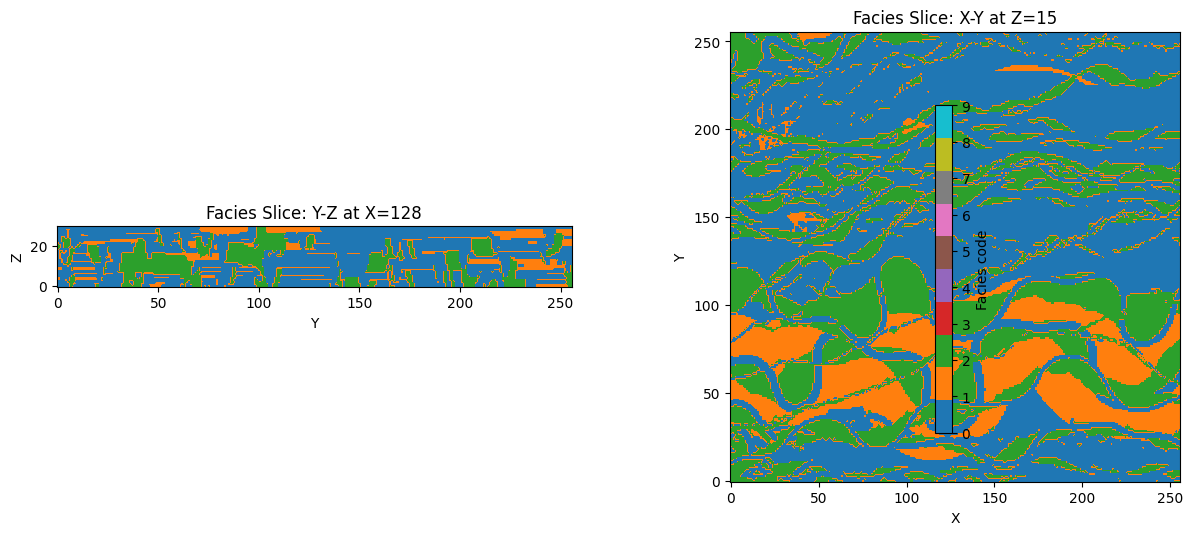

In [3]:
# Slice visualization in two orthogonal planes
nx, ny, nz = facies_block.shape
x_mid = nx // 2
z_mid = nz // 2

slice_x = facies_block[x_mid, :, :]
slice_z = facies_block[:, :, z_mid]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(slice_x.T, origin="lower", cmap="tab10", vmin=0, vmax=9)
axes[0].set_title(f"Facies Slice: Y-Z at X={x_mid}")
axes[0].set_xlabel("Y")
axes[0].set_ylabel("Z")

im1 = axes[1].imshow(slice_z.T, origin="lower", cmap="tab10", vmin=0, vmax=9)
axes[1].set_title(f"Facies Slice: X-Y at Z={z_mid}")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")

cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.85)
cbar.set_label("Facies code")
plt.tight_layout()
plt.show()

rms shape: (256, 256)
rms range: 0.0055935923010110855 0.24543654918670654
normalized rms range: -0.9792227745056152 0.9774101972579956


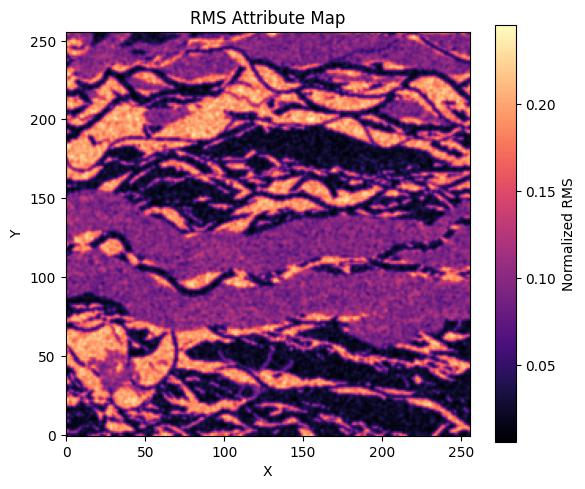

In [6]:
# Generate RMS map at a target depth and visualize
from diffsim.data.seismic import DEFAULT_ROCK_PROPERTIES, normalize_cube_to_range


rms_cube = generate_rms_from_facies_3d(
    facies_block,
    rock_properties=DEFAULT_ROCK_PROPERTIES,
    f_dominant=25.0,
    rms_window_half=3,
    noise_level=0.03,
    smooth_sigma=0.8,
    rng=rng,
)

norm_cube = normalize_cube_to_range(rms_cube, vmin=-1.0, vmax=1.0)

rms_map = rms_cube[:, :, z_mid]
norm_rms_map = norm_cube[:, :, z_mid]

print("rms shape:", rms_map.shape)
print("rms range:", float(rms_map.min()), float(rms_map.max()))
print("normalized rms range:", float(norm_rms_map.min()), float(norm_rms_map.max()))


fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(rms_map.T, origin="lower", cmap="magma")
ax.set_title("RMS Attribute Map")
ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.colorbar(im, ax=ax, label="Normalized RMS")
plt.tight_layout()
plt.show()

## Notes

- Facies encoding uses 0=mud, 1=bank, 2=sand.
- AI is derived from facies using default rock-property mapping.
- Reflectivity is vertical and has one fewer sample along Z.
- RMS is normalized to the range [-1, 1] in the seismic utility pipeline.